Code below from IBM VQE tutorial

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

In [29]:
hamiltonian = SparsePauliOp.from_list([
    ("YZ", 0.3980),
    ("ZI", -0.3980),
    ("ZZ", -0.0113),
    ("XX", 0.1810),
])

print(hamiltonian)

SparsePauliOp(['YZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[ 0.398 +0.j, -0.398 +0.j, -0.0113+0.j,  0.181 +0.j])


In [30]:
A = hamiltonian.to_matrix()

eigenvalues, eigenvectors = np.linalg.eigh(A)

ground_energy = eigenvalues[0]

print("Ground-state energy:")
print(ground_energy)

Ground-state energy:
-0.702930394459531


Number of parameters: 4


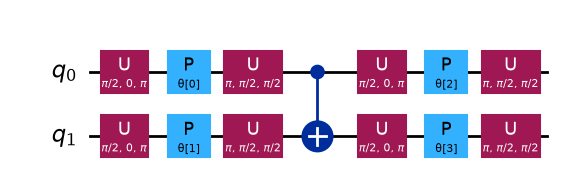

In [31]:
ansatz = efficient_su2(
    hamiltonian.num_qubits,
    su2_gates=["h", "rz", "y"],
    entanglement="circular",
    reps = 1
)

print("Number of parameters:", ansatz.num_parameters)

ansatz.decompose().draw("mpl")

In [32]:
estimator = StatevectorEstimator()

In [33]:
cost_history = {
    "iters": 0,
    "energies": [],
}

In [34]:
def cost_function(params, ansatz, hamiltonian, estimator):

    pub = (ansatz, [hamiltonian], [params])

    result = estimator.run([pub]).result()

    energy = result[0].data.evs[0]

    cost_history["iters"] += 1
    cost_history["energies"].append(energy)

    print(
        f"Iteration {cost_history['iters']:2d}"
        f"   Energy = {energy:.8f}"
    )

    return energy

In [35]:
x0 = 2*np.pi*np.random.random(ansatz.num_parameters)

print(x0)

[5.18587052 3.42960775 3.28881192 0.72646522]


In [36]:
result = minimize(
    cost_function,
    x0,
    args=(ansatz, hamiltonian, estimator),
    method="COBYLA",
    options={"maxiter": 50},
)

Iteration  1   Energy = 0.48480022
Iteration  2   Energy = 0.42831862
Iteration  3   Energy = 0.24219850
Iteration  4   Energy = 0.07653267
Iteration  5   Energy = 0.25401161
Iteration  6   Energy = -0.28846116
Iteration  7   Energy = -0.35263131
Iteration  8   Energy = -0.39689037
Iteration  9   Energy = -0.58223772
Iteration 10   Energy = 0.17369142
Iteration 11   Energy = -0.55884653
Iteration 12   Energy = -0.60219498
Iteration 13   Energy = -0.41242917
Iteration 14   Energy = -0.63504787
Iteration 15   Energy = -0.50764938
Iteration 16   Energy = -0.64690248
Iteration 17   Energy = -0.67246438
Iteration 18   Energy = -0.66206985
Iteration 19   Energy = -0.66814876
Iteration 20   Energy = -0.67180810
Iteration 21   Energy = -0.67722729
Iteration 22   Energy = -0.68637138
Iteration 23   Energy = -0.68777404
Iteration 24   Energy = -0.68983755
Iteration 25   Energy = -0.68140760
Iteration 26   Energy = -0.68934096
Iteration 27   Energy = -0.69644786
Iteration 28   Energy = -0.6978467

In [37]:
print()

print("VQE energy:")
print(result.fun)

print()

print("Exact energy:")
print(ground_energy)


VQE energy:
-0.7024478636171371

Exact energy:
-0.702930394459531


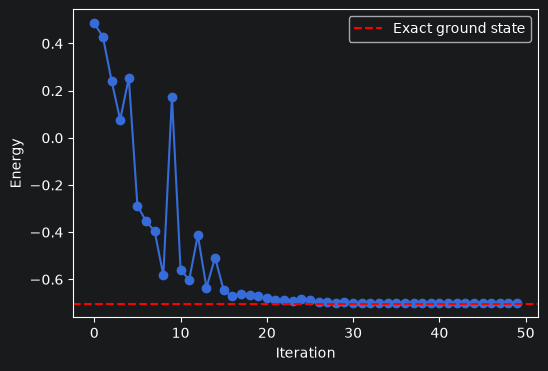

In [38]:
plt.figure(figsize=(6,4))

plt.plot(cost_history["energies"], marker="o")

plt.axhline(
    ground_energy,
    color="red",
    linestyle="--",
    label="Exact ground state"
)

plt.xlabel("Iteration")
plt.ylabel("Energy")

plt.legend()

plt.show()